In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("Lab_6_classes_and_drawing.ipynb")

# Lab 6: Classes and drawing

Slides for the lab:
https://docs.google.com/presentation/d/1N7vEXDZVZikuHGMLDHB3lX1q4pSNJdKxboy5Sto-Dl0/edit?usp=sharing 

The goal of this lab is to use classes to draw and animate a quarter of a car. Whereas a whole car has four tires that are each suspended off of the car body, a quarter car has a single tire suspended off of a car body. 

See the lecture notes for a diagram of the dynamic model of a quarter car.

In the diagram, $m_s$ is the mass of the car body (sprung mass), $m_u$ is the mass of the wheel itself (unsprung mass), $c_s$ is the damping constant of the suspension, $k_s$ is the spring constant of the suspension, and $k_t$ is the spring constant of the tire.

Next, see the lecture notes for an image of how we plan to draw a quarter car.

In this picture, the red square is the car body, blue square is the wheel mass, the squiggles are the two springs (the suspension above the wheel, and the tire below the wheel), and the cylinder with the plunger-like piston is the suspension's damper. The simulation will vary the positions and, for the springs, sizes of some of these items, so we need a robust way to draw the car in a variety of situations.

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
# Enable animations to work
%matplotlib widget

## Part 1: Paste in `draw_spring` function from lecture activity 6

We need to draw a quarter car at rest. Start by pasting in your `draw_spring` function from lecture activity 6.

In [3]:
def draw_spring(axs, width, height, x=0, y=0):
    # GUIDES: Paste in implementation from lecture activity 6.
    """
    Draws a spring, starting at x and y, with the given width and height.
    The spring ends in two rods that are each 5% of the total height, and the middle contains
    three coils.

    You can ignore x and y for the first part of the problem.
    """
    x_values = np.zeros(10)
    y_values = np.zeros(10)

    half_amp = width / 2
    rod_step = height * 0.05
    height_steps = (height - 2 * rod_step) / 3
    
    # x-values
    for i in range(0, 10):
        if i < 2 or i > 7:
            x_values[i] = x
        else:
            if i % 2 == 0:
                x_values[i] = x + half_amp
            elif i % 2 != 0:
                x_values[i] = x - half_amp
            else:
                print("Error")

    # y-values
    y_values[0] = y
    y_values[1] = y + rod_step
    y_values[9] = y + height
    for i in range(2, 9):
        if i % 2 == 0:
            y_values[i] = y_values[i-1]
        elif i % 2 != 0:
            y_values[i] = y_values[i-1] + height_steps
        else:
            print("error")
    
    axs.plot(x_values, y_values, color="black")

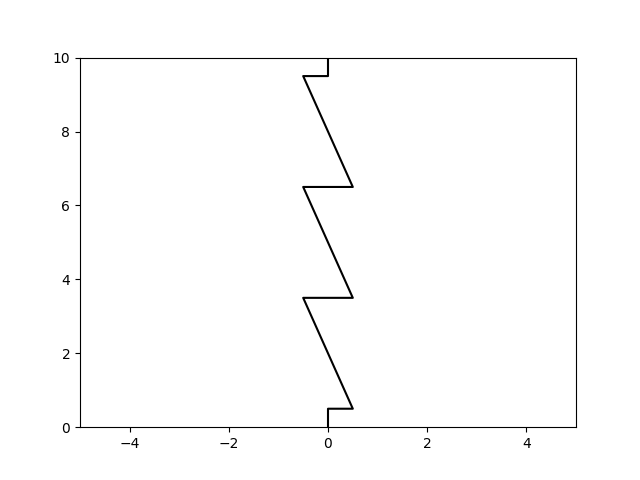

In [4]:
# Check code - draw a tall spring
fig_tall, axs_tall = plt.subplots()
axs_tall.set_xlim([-5, 5])
axs_tall.set_ylim([0, 10])
draw_spring(axs=axs_tall, width=1, height=10)
plt.show()

In [5]:
grader.check("draw_spring")

draw_spring results: All test cases passed!

## Part 2: Draw a damper

The next most interesting thing we need to draw is the damper. In our quarter car, the damper is a U-shaped cylinder with squared corners that has a piston inside. The piston is attached to a rod of a fixed, constant size that is attached to the sprung mass (car body). The bottom of the cylinder has a small fixed-size rod connected to the unsprung mass (wheel). The position of the piston within the cylinder is a function of the y position of the sprung ($y_s$) and unsprung mass ($y_u$); as they move closer together, the piston compresses.

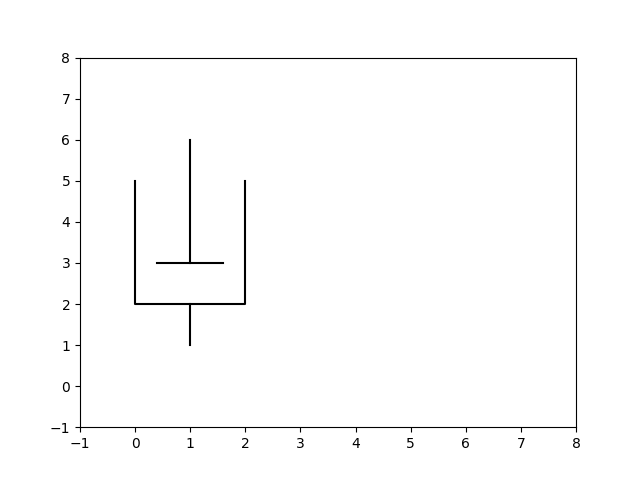

In [6]:
fig_damper, axs_damper = plt.subplots()
axs_damper.set_xlim([-1, 8])
axs_damper.set_ylim([-1, 8])

# Location of center of cylinder
x = 1
# Unsprung mass is at y=1
y_u = 1
# Sprung mass is at y=6
y_s = 6
# Height of rod attached to unsprung mass
rod_u_height = 1
# Height of rod attached to sprung mass.
rod_s_height = 3
# Cylinder radius (making the cylinder width = 2*radius)
cylinder_radius = 1
cylinder_height = 3

rod_u_X = np.array([x, x])
rod_u_Y = np.array([y_u, y_u + rod_u_height])
axs_damper.plot(rod_u_X, rod_u_Y, 'k')

rod_s_X = np.array([x, x])
rod_s_Y = np.array([y_s, y_s - rod_s_height])
axs_damper.plot(rod_s_X, rod_s_Y, 'k')

# Cylinder of width 2 and height 5, begins just above the unsprung rod.
cylinder_X = np.array([-cylinder_radius, -cylinder_radius, cylinder_radius, cylinder_radius]) + x
cylinder_Y = np.array([cylinder_height, 0, 0, cylinder_height]) + y_u + rod_u_height
axs_damper.plot(cylinder_X, cylinder_Y, 'k')

# Make piston 60% of the width of the cylinder, and center it within the cylinder.
piston_X = np.array([-0.6*cylinder_radius, 0.6*cylinder_radius]) + x
piston_Y = np.array([y_s - rod_s_height, y_s - rod_s_height])
axs_damper.plot(piston_X, piston_Y, 'k')


plt.show()

In [7]:
def draw_damper(axs, x, y_u, y_s, width, height, rod_u_height, rod_s_height):
    """
    Draw a damper.
    @param axs The axs to draw the damper in.
    @param x the x coordinate to draw the damper at. the damper should be centered at x.
    @param width the width of the damper
    @param height the height of the damper.
    @param y_u the y coordinate of the unsprung mass,
    @param y_s the y coordinate of the sprung mass.
    @param rod_u_height the height of the rod stuck in the unsprung mass, and
    @param rod_s_height the height of the rod stuck in the sprung mass.
    """
    radius = width / 2

    rod_u_X = np.array([x, x])
    rod_u_Y = np.array([y_u, y_u + rod_u_height])
    axs.plot(rod_u_X, rod_u_Y, 'k')

    rod_s_X = np.array([x, x])
    rod_s_Y = np.array([y_s, y_s - rod_s_height])
    axs.plot(rod_s_X, rod_s_Y, 'k')

    # Cylinder of width 2 and height 5, begins just above the unsprung rod.
    cylinder_X = np.array([-radius, -radius, radius, radius]) + x
    cylinder_Y = np.array([height, 0, 0, height]) + y_u + rod_u_height
    axs.plot(cylinder_X, cylinder_Y, 'k')

    # Make piston 60% of the width of the cylinder, and center it within the cylinder.
    piston_X = np.array([-0.6*radius, 0.6*radius]) + x
    piston_Y = np.array([y_s - rod_s_height, y_s - rod_s_height])
    axs.plot(piston_X, piston_Y, 'k')

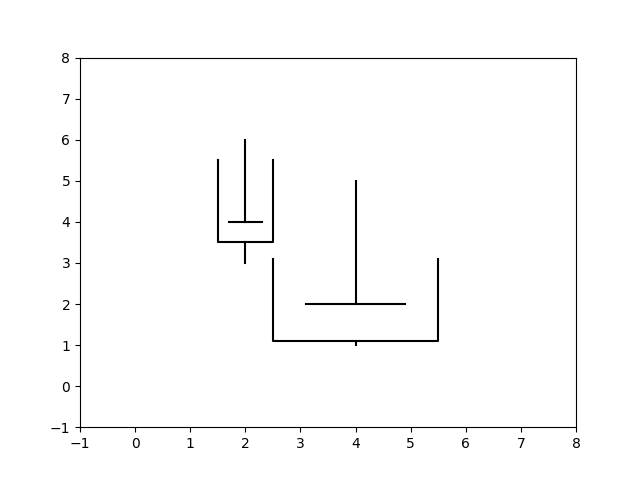

In [8]:
# Check code: Plot two dampers at different locations with different sizes.
fig_dampers, axs_dampers = plt.subplots()
axs_dampers.set_xlim([-1, 8])
axs_dampers.set_ylim([-1, 8])

draw_damper(axs_dampers, x=2, y_u=3, y_s=6, width=1, height=2, rod_u_height=0.5, rod_s_height=2)
draw_damper(axs_dampers, x=4, y_u=1, y_s=5, width=3, height=2, rod_u_height=0.1, rod_s_height=3)

plt.show()

In [9]:
grader.check("draw_damper")

draw_damper results: All test cases passed!

## Part 3: Drawing masses

Next, we need to draw the square for the sprung mass (car body) and the unsprung masses (the wheels). Numpy has a method for drawing polygons -- `axs.fill`. All we need to do is tell it the four (x,y) points in the polygon.

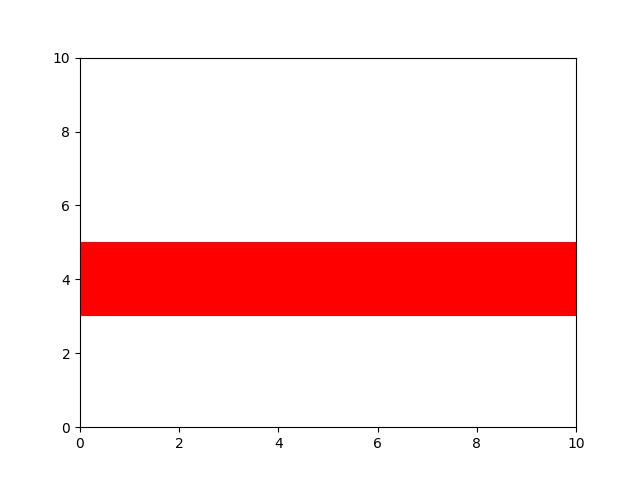

In [10]:
fig_polygon, axs_polygon = plt.subplots()
axs_polygon.set_ylim(0, 10)
axs_polygon.set_xlim(0, 10)
# Draws a red polygon of width 10 and height 2 centered around x=5 and starting at y=3
axs_polygon.fill([0, 10, 10, 0], [3, 3, 5, 5], 'r')
plt.show()

In [11]:
def draw_rectangle(axs, width, height, x, y, color):
    """
    Draw a rectangle with the given `width` and `height` at the given `x` and `y` coordinates.
    The lower-left corner of the rectangle should be at (x, y).
    """
    x_values = [x, x + width, x + width, x]
    y_values = [y, y, y + height, y + height]

    axs.fill(x_values, y_values, 'r', color=color)

C:\Users\JPizzle\AppData\Local\Temp\ipykernel_4700\3425257766.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  axs.fill(x_values, y_values, 'r', color=color)


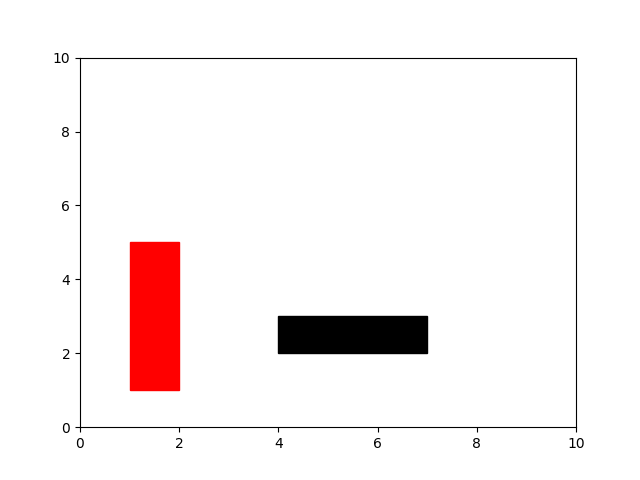

In [12]:
# Check code: Draw two rectangles with different colors.
fig_polygon2, axs_polygon2 = plt.subplots()
axs_polygon2.set_ylim(0, 10)
axs_polygon2.set_xlim(0, 10)
draw_rectangle(axs_polygon2, width=3, height=1, x=4, y=2, color='k')
draw_rectangle(axs_polygon2, width=1, height=4, x=1, y=1, color='r')

In [13]:
grader.check("draw_masses")

draw_masses results: All test cases passed!

## Part 4: Draw tires

The final part of our car we need to draw are the tires, which are just circles. We can use a simple matplotlib marker for this purpose.

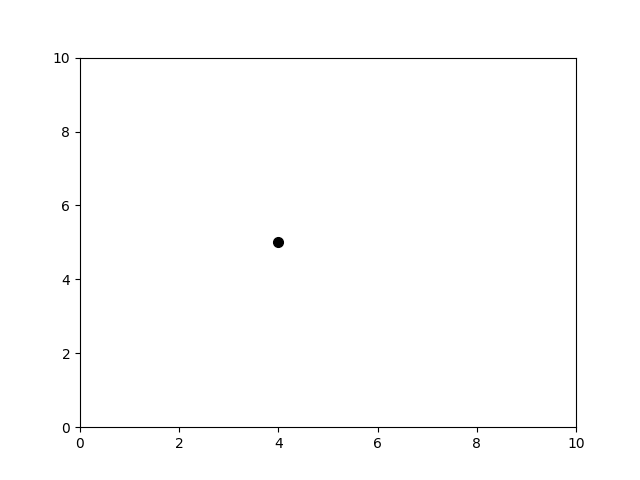

In [14]:
fig_tire, axs_tire = plt.subplots()
axs_tire.set_ylim(0, 10)
axs_tire.set_xlim(0, 10)


# Plot a single tire at x=4, y=5.
# 'k' = black, 'o' = circle, so 'ko' means 'black circle'
tire, = axs_tire.plot(4, 5, 'ko')
tire.set_markersize(7)
plt.show()

In [15]:
def draw_tire(axs, x, y):
    """
    Draw a tire at (x, y).
    """
    tire, = axs.plot(x, y, 'ko')
    tire.set_markersize(7)

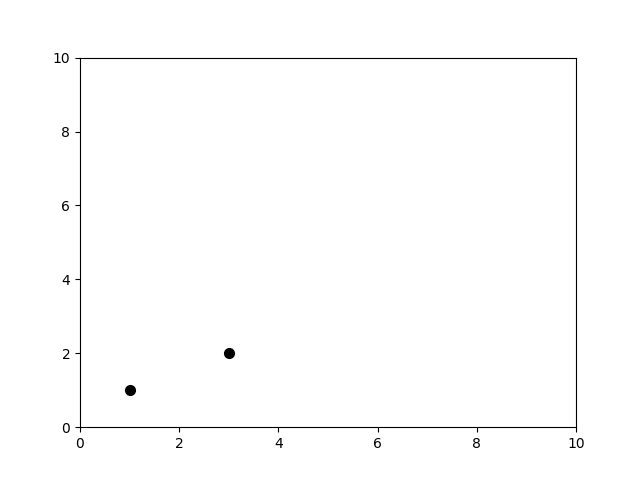

In [16]:
# Check code: Draw two tires at different locations
fig_tires, axs_tires = plt.subplots()
axs_tires.set_ylim(0, 10)
axs_tires.set_xlim(0, 10)
draw_tire(axs_tires, 1, 1)
draw_tire(axs_tires, 3, 2)

In [17]:
grader.check("draw_tires")

draw_tires results: All test cases passed!

## Part 5: Draw a quarter car

It can be really hard to think about the whole `QuarterCar` at once. Classes are very useful ways of "encapsulating" data and functionality. We can use classes to encapsulate the knowledge needed to draw a quarter car.

When it comes to drawing a `QuarterCar`, there are many properties that are fixed, and a few that are influenced by the dynamic system comprised of the masses, springs, damper, and external forces.

The few properties influenced by the dynamic system are:

* The `x` coordinate is dictated by the car's position on a 2-D "road" (a line).
* The `y` coordinate the tire is dictated by the road location ($y_r$) at that `x` coordinate.
* The `y` coordinate of the sprung mass ($y_s$) and the unsprung mass ($y_u$) are influenced by the forces acting on the whole `QuarterCar` system, which we will discuss in a future assignment.

These properties then directly dictate:

* The length of the springs, since they bridge the tire and the unsprung mass, and the unsprung mass and the sprung mass.
* The `y` coordinates of each component in the damper, as it is directly attached to the sprung and unsprung masses.

The fixed properties, which do not vary, are:

* The width and height of the sprung mass ($w_s$, $h_s$) and unsprung mass ($w_u$, $h_u$).
* The width of the suspension spring ($w_{ss}$) and tire spring ($w_{ts}$)
* The width and height of the damper cylinder ($w_c$, $h_c$)
* The height of the sprung mass and unsprung mass rods ($h_{rs}$, $h_{ru}$)
* The distance between the suspension spring and suspension damper ($d_s$)
* The at-rest distance between the ground and the unsprung mass ($y_{u_{static}}$)
* The at-rest distance between the ground and the sprung mass ($y_{s_{static}}$).

There are also fun properties that could be set, like the color to draw various bits of the car.

Thus, we should be able to package all of the logic needed to draw a `QuarterCar` into a function on a `car` object that only accepts a few external variables:

```python
car.draw(axs, x, y_s, y_u, y_r)
```

The car itself can be constructed with the fixed properties passed into the `__init__` function:

```python
car = QuarterCar(w_s=..., h_s=..., w_u=..., h_u=..., w_ss=..., w_ts=..., w_c=..., h_c=..., h_rs=..., h_ru=..., d_s=..., y_u_static=..., y_s_static=...)
```

In [18]:
class QuarterCar:
    def __init__(self, w_s=1.4, h_s=0.1, w_u=0.5, h_u=0.1, w_ss=0.1, w_ts=0.07, w_c=0.14, h_c=0.5, h_rs=0.49, h_ru=0.09, d_s=0.3, y_s_static=1.6, y_u_static=0.7):
        self.w_s = w_s # width sprung mass
        self.h_s = h_s # height sprung mass
        self.w_u = w_u # width unsprung mass
        self.h_u = h_u # height unsprung mass
        self.w_ss = w_ss # width suspension spring
        self.w_ts = w_ts # width tire spring
        self.w_c = w_c # width damper cylinder
        self.h_c = h_c # height damper cylinder
        self.h_rs = h_rs # height sprung mass rod
        self.h_ru = h_ru # height unsprung mass rod
        self.d_s = d_s # distance between suspension spring & damper
        self.y_u_static = y_u_static # at rest distance between ground and unsprung mass
        self.y_s_static = y_s_static # at rest distance between ground and sprung mass

    def draw(self, axs, x, y_s, y_u, y_r):
        # y_s and y_u are adjustments over y_u_static / y_s_static.
        y_u = y_u + self.y_u_static
        y_s = y_s + self.y_s_static

        # Draw tire on the road.
        draw_tire(axs, x, y_r)

        # Draw the sprung mass, and make it red ('r'). We move the x position to be in the middle of the spring mass.
        draw_rectangle(axs, width=self.w_s, height=self.h_s, x=x - (self.w_s/2), y=y_s, color='r')

        # GUIDES: Draw the unsprung mass, and make it blue ('b')
        draw_rectangle(axs, width=self.w_u, height=self.h_u, x=x - (self.w_u/2), y=y_u, color='b')

        # Draw the tire spring from the road to the unsprung mass
        draw_spring(axs, width=self.w_ts, height=y_u - y_r, x=x, y=y_r)

        # GUIDES: Draw the suspension spring from the unsprung mass to the sprung mass.
        # Hint: Don't forget to account for the height of the unsprung mass!
        # Place the spring at the furthest x position such that the entire spring is over the unsprung mass,
        # and store that x position into x_ss.
        x_ss = (x - self.w_u / 2) + self.w_ss / 2
        draw_spring(axs, width=self.w_ss, height=y_s - y_u - self.h_u, x=x_ss, y=y_u + self.h_u)

        # Draw the damper from the unsprung mass to the sprung mass.
        # It's drawn at an x coordinate relative to the suspension spring.
        draw_damper(axs, x=x_ss + self.d_s, y_u=y_u + self.h_u, y_s=y_s, width=self.w_c, height=self.h_c, rod_u_height=self.h_ru, rod_s_height=self.h_rs)


C:\Users\JPizzle\AppData\Local\Temp\ipykernel_4700\3425257766.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  axs.fill(x_values, y_values, 'r', color=color)


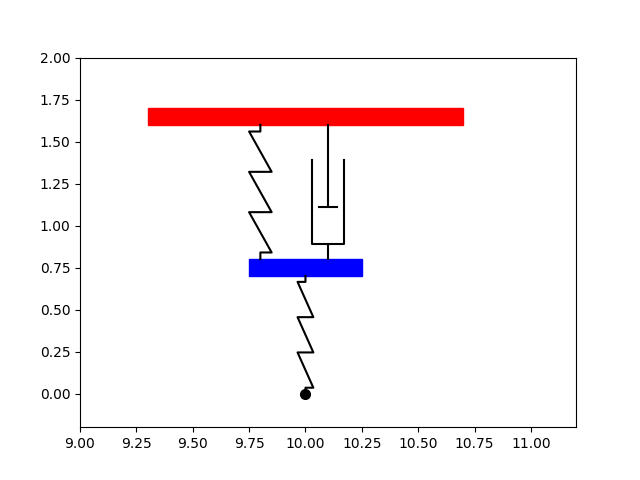

In [19]:
# Check code: Draw a quarter car.
car = QuarterCar()

fig_car, axs_car = plt.subplots()
axs_car.set_ylim([-0.2, 2])
axs_car.set_xlim([9, 11.2])
car.draw(axs_car, x=10, y_s=0, y_u=0, y_r=0)
plt.show()

In [20]:
grader.check("draw_quarter_car")

draw_quarter_car results: All test cases passed!

## Part 6: Animating the quarter car!

Now we can animate your car with the `draw` function!

In [21]:
data = np.load("Data/quarter_car_anim_bump.npy")
y_s = data[0]
y_u = data[1]
y_r = data[2]
x = np.linspace(0, 5, len(y_s))

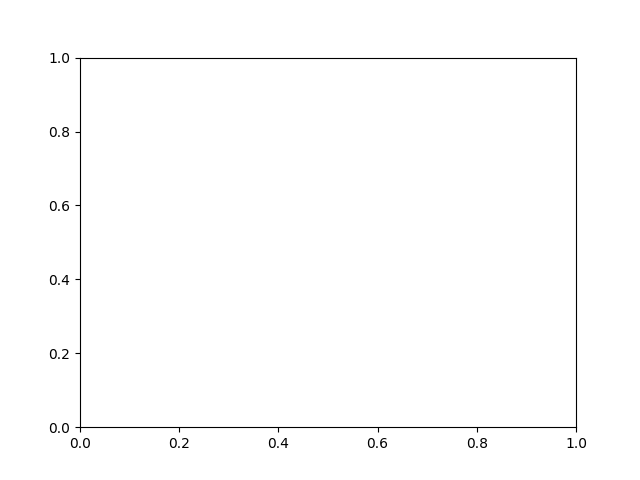

In [22]:
fig_caranim, axs_caranim = plt.subplots()

def draw_car_frame(i):
    axs_caranim.clear()
    axs_caranim.set_ylim([-0.1, 2.5])
    axs_caranim.set_xlim([x[i] - 1.2, x[i] + 1.2])
    axs_caranim.plot(x, y_r, 'k')
    car.draw(axs_caranim, x[i], y_s[i], y_u[i], y_r[i])

# We disable repeats for animations because the animation will repeat forever, which can cause issues when re-running a cell.
car_anim = animation.FuncAnimation(fig_caranim, draw_car_frame, frames=len(x), interval=1/30 * 1000, repeat=False)
plt.show()

In the next lab, you will learn how to simulate the quarter car system to produce animations like the above.

## Hours and collaborators
Required for every assignment - fill out before you hand-in.

Listing names and websites helps you to document who you worked with and what internet help you received in the case of any plagiarism issues. You should list names of anyone (in class or not) who has substantially helped you with an assignment - or anyone you have *helped*. You do not need to list TAs.

Listing hours helps us track if the assignments are too long.

In [23]:

# List of names (creates a set)
worked_with_names = {"n/a"}
# List of URLS SP26 (creates a set)
websites = {"n/a"}
# Approximate number of hours, including lab/in-class time
hours = 1

In [24]:
grader.check("hours_collaborators")

hours_collaborators results: All test cases passed!

### To submit

Double check your plots. 

- Submit this .ipynb file to Lab 6 (classes and drawing)

Failures: None expected